In [1]:
print("Customer Churn Project")

Customer Churn Project


In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("telco-customer-churn-by-IBM.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

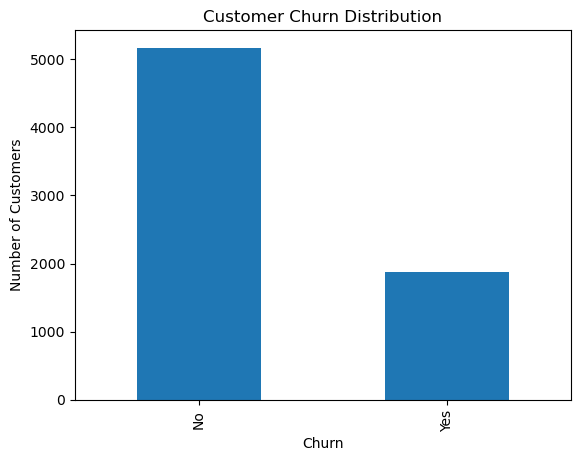

In [11]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [12]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [13]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [14]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [15]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [16]:
df[["tenure", "TenureGroup"]].head(10)

,tenure,TenureGroup
0,1,0-6 months
1,34,25-48 months
2,2,0-6 months
3,45,25-48 months
4,2,0-6 months
5,8,7-12 months
6,22,13-24 months
7,10,7-12 months
8,28,25-48 months
9,62,49-72 months


In [17]:
pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TenureGroup,,
0-6 months,46.666667,53.333333
7-12 months,64.113475,35.886525
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


In [18]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

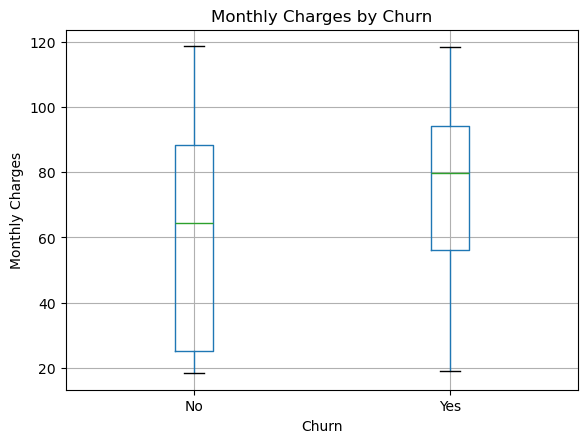

In [19]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [20]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [21]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [22]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [23]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [24]:
df.dtypes

customerID            object
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges          object
Churn                 object
TenureGroup         category
dtype: object

In [25]:
ml_df = df.drop(["customerID", "TenureGroup"], axis=1)

In [26]:
ml_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

In [28]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [29]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [30]:
y = y.map({"No": 0, "Yes": 1})

In [31]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [32]:
X = pd.get_dummies(X, drop_first=True)

In [33]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [34]:
ml_df["TotalCharges"] = pd.to_numeric(
    ml_df["TotalCharges"],
    errors="coerce"
)

In [35]:
ml_df["TotalCharges"].isnull().sum()

np.int64(11)

In [36]:
ml_df = ml_df.dropna(subset=["TotalCharges"])

In [37]:
ml_df.shape

(7032, 20)

In [38]:
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

In [39]:
y = y.map({"No": 0, "Yes": 1})

In [40]:
X = pd.get_dummies(X, drop_first=True)

In [41]:
X.shape

(7032, 30)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))
print("Training churn labels:", len(y_train))
print("Testing churn labels:", len(y_test))

Training customers: 5625
Testing customers: 1407
Training churn labels: 5625
Testing churn labels: 1407


In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model = LogisticRegression(max_iter=1000)

In [47]:
model = LogisticRegression(max_iter=5000)

In [48]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [49]:
y_pred = model.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8052594171997157


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[917 116]
 [158 216]]


In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.58      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [53]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.836107645557563


In [54]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,1.219127
21,StreamingTV_Yes,0.414966
23,StreamingMovies_Yes,0.387874
9,MultipleLines_Yes,0.385475
28,PaymentMethod_Electronic check,0.384934
8,MultipleLines_No phone service,0.338591
26,PaperlessBilling_Yes,0.294603
0,SeniorCitizen,0.193626
17,DeviceProtection_Yes,0.096211
29,PaymentMethod_Mailed check,0.077773


In [55]:
coefficients.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

,Feature,Coefficient
25,Contract_Two year,-1.374080
24,Contract_One year,-0.744354
13,OnlineSecurity_Yes,-0.350292
19,TechSupport_Yes,-0.310191
6,Dependents_Yes,-0.227868
18,TechSupport_No internet service,-0.182500
11,InternetService_No,-0.182500
12,OnlineSecurity_No internet service,-0.182500
22,StreamingMovies_No internet service,-0.182500
16,DeviceProtection_No internet service,-0.182500


In [56]:
churn_probability = model.predict_proba(X_test)[:, 1]

print(churn_probability[:10])

[0.01748506 0.59181749 0.00451179 0.20225774 0.10402547 0.4730112
 0.02574919 0.16481288 0.67996215 0.01493225]


In [57]:
risk_level = pd.cut(
    churn_probability,
    bins=[0, 0.30, 0.60, 1],
    labels=["Low", "Medium", "High"]
)

print(risk_level[:10])

['Low', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'Low', 'Low', 'High', 'Low']
Categories (3, object): ['Low' < 'Medium' < 'High']


In [59]:
customer_risk["Risk_Level"] = risk_level

In [60]:
customer_risk.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Churn_Probability,Risk_Level
974,0,59,75.95,4542.35,False,True,True,True,False,False,...,True,False,True,True,True,False,False,0,0.017485,Low
619,0,7,78.55,522.95,False,False,False,True,False,True,...,False,False,False,True,False,False,False,0,0.591817,Medium
4289,0,54,20.10,1079.45,False,False,False,True,False,False,...,False,False,True,False,False,False,True,0,0.004512,Low
3721,0,2,20.65,38.70,False,False,False,True,False,False,...,False,False,False,False,False,False,True,1,0.202258,Low
4533,0,71,105.15,7555.00,False,True,False,True,False,True,...,True,False,True,True,False,False,False,0,0.104025,Low


In [61]:
customer_risk["Risk_Level"].value_counts()

Risk_Level
Low       854
Medium    341
High      212
Name: count, dtype: int64

In [62]:
customer_risk["Risk_Level"].value_counts(normalize=True) * 100

Risk_Level
Low       60.696517
Medium    24.235963
High      15.067520
Name: proportion, dtype: float64

In [63]:
high_risk_customers = customer_risk[
    customer_risk["Risk_Level"] == "High"
]

high_risk_customers.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Churn_Probability,Risk_Level
1346,0,14,87.25,1258.60,False,True,True,True,False,True,...,True,False,False,True,False,True,False,1,0.679962,High
4283,1,4,70.20,280.35,True,True,False,True,False,False,...,False,False,False,True,False,True,False,0,0.707476,High
6128,0,14,78.10,1122.40,False,True,False,True,False,False,...,True,False,False,True,False,True,False,0,0.653240,High
346,0,2,90.40,168.20,False,False,False,True,False,False,...,True,False,False,True,False,True,False,1,0.774366,High
6718,0,3,75.00,209.10,True,False,False,True,False,True,...,False,False,False,False,False,False,True,1,0.608633,High
3682,0,1,69.10,69.10,True,False,False,True,False,False,...,False,False,False,True,False,True,False,1,0.699009,High
139,1,1,70.45,70.45,False,True,False,True,False,False,...,False,False,False,True,False,False,True,1,0.668496,High
2968,0,3,90.40,268.45,True,False,False,True,False,False,...,True,False,False,False,False,True,False,0,0.613571,High
53,1,8,80.65,633.30,False,True,False,True,False,True,...,False,False,False,True,True,False,False,1,0.625958,High
4154,0,6,74.90,469.80,True,False,False,True,False,True,...,False,False,False,True,False,True,False,1,0.721741,High


In [64]:
risk_results = df.loc[
    X_test.index,
    ["customerID", "Contract", "tenure", "MonthlyCharges", "Churn"]
].copy()

risk_results["Churn_Probability"] = churn_probability
risk_results["Risk_Level"] = risk_level

risk_results.head(10)

,customerID,Contract,tenure,MonthlyCharges,Churn,Churn_Probability,Risk_Level
974,0604-THJFP,Two year,59,75.95,No,0.017485,Low
619,4059-IIEBK,Month-to-month,7,78.55,No,0.591817,Medium
4289,2228-BZDEE,Two year,54,20.10,No,0.004512,Low
3721,2839-RFSQE,Month-to-month,2,20.65,Yes,0.202258,Low
4533,5360-LJCNJ,Two year,71,105.15,No,0.104025,Low
445,7752-XUSCI,Month-to-month,60,105.90,Yes,0.473011,Medium
5898,8277-RVRSV,One year,33,24.15,No,0.025749,Low
3387,3530-CRZSB,Month-to-month,7,20.65,No,0.164813,Low
1346,2845-HSJCY,Month-to-month,14,87.25,Yes,0.679962,High
5690,0336-KXKFK,Two year,72,61.20,No,0.014932,Low


In [65]:
risk_results.sort_values(
    by="Churn_Probability",
    ascending=False
).head(10)

,customerID,Contract,tenure,MonthlyCharges,Churn,Churn_Probability,Risk_Level
3380,5178-LMXOP,Month-to-month,1,95.10,Yes,0.846828,High
3159,5150-ITWWB,Month-to-month,3,94.85,No,0.845336,High
2631,6861-XWTWQ,Month-to-month,7,99.25,Yes,0.825979,High
4585,1069-XAIEM,Month-to-month,1,85.05,Yes,0.822234,High
582,2865-TCHJW,Month-to-month,4,89.20,Yes,0.815087,High
2797,6023-YEBUP,Month-to-month,3,100.95,Yes,0.814949,High
3727,9057-SIHCH,Month-to-month,3,96.60,Yes,0.814639,High
933,4750-ZRXIU,Month-to-month,4,84.60,Yes,0.810372,High
6240,6521-YYTYI,Month-to-month,1,93.30,Yes,0.793653,High
5213,7668-XCFYV,Month-to-month,17,92.55,No,0.790744,High


In [66]:
risk_results.to_csv("customer_churn_predictions.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [67]:
pd.crosstab(
    risk_results["Risk_Level"],
    risk_results["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Risk_Level,,
Low,89.344262,10.655738
Medium,59.237537,40.762463
High,32.075472,67.924528


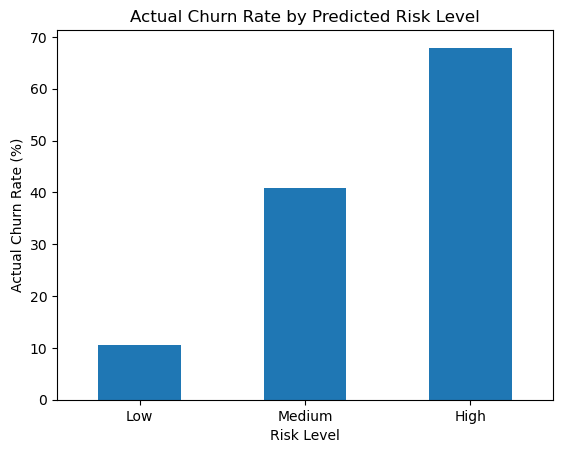

In [68]:
risk_churn_rate = pd.crosstab(
    risk_results["Risk_Level"],
    risk_results["Churn"],
    normalize="index"
) * 100

risk_churn_rate["Yes"].plot(kind="bar")

plt.title("Actual Churn Rate by Predicted Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Actual Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [69]:
high_risk = risk_results[risk_results["Risk_Level"] == "High"]

print("High-Risk Customers:", len(high_risk))
print("Actually Churned:", (high_risk["Churn"] == "Yes").sum())

High-Risk Customers: 212
Actually Churned: 144


In [71]:
risk_results.groupby(
    "Risk_Level",
    observed=True
)["MonthlyCharges"].mean()

Risk_Level
Low       56.101815
Medium    73.400440
High      80.657311
Name: MonthlyCharges, dtype: float64

In [72]:
pd.crosstab(
    risk_results["Risk_Level"],
    risk_results["Contract"],
    normalize="index"
) * 100

Contract,Month-to-month,One year,Two year
Risk_Level,,,
Low,29.859485,31.850117,38.290398
Medium,94.721408,5.278592,0.000000
High,100.000000,0.000000,0.000000


In [73]:
high_risk["Contract"].value_counts()

Contract
Month-to-month    212
Name: count, dtype: int64

In [75]:
df.loc[high_risk.index, "InternetService"].value_counts()

InternetService
Fiber optic    199
DSL             13
Name: count, dtype: int64

In [76]:
df.loc[high_risk.index, "tenure"].mean()

np.float64(7.976415094339623)

In [77]:
df.loc[X_test.index, "tenure"].mean()

np.float64(31.85998578535892)

In [78]:
risk_results.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

print("Final prediction file saved!")

Final prediction file saved!


In [79]:
risk_summary = risk_results.groupby(
    "Risk_Level",
    observed=True
).agg(
    Customers=("customerID", "count"),
    Avg_Monthly_Charges=("MonthlyCharges", "mean")
)

risk_summary

,Customers,Avg_Monthly_Charges
Risk_Level,,
Low,854,56.101815
Medium,341,73.400440
High,212,80.657311


In [80]:
risk_summary.to_csv(
    "risk_summary.csv"
)

print("Risk summary saved!")

Risk summary saved!


In [81]:
final_data = df.dropna(subset=["TotalCharges"]).copy()

final_data["Churn_Probability"] = None
final_data["Risk_Level"] = None

final_data.loc[X_test.index, "Churn_Probability"] = churn_probability
final_data.loc[X_test.index, "Risk_Level"] = risk_level

final_data.to_csv(
    "final_customer_churn_data.csv",
    index=False
)

print("Final dataset saved!")

Final dataset saved!


In [3]:
import pandas as pd

df = pd.read_csv("telco-customer-churn-by-IBM.csv")

print(df.shape)

(7043, 21)


In [4]:
ml_df = df.drop(["customerID"], axis=1).copy()

ml_df["TotalCharges"] = pd.to_numeric(
    ml_df["TotalCharges"],
    errors="coerce"
)

ml_df = ml_df.dropna(subset=["TotalCharges"])

print(ml_df.shape)

(7032, 20)


In [5]:
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

y = y.map({"No": 0, "Yes": 1})

X = pd.get_dummies(X, drop_first=True)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X.shape)
print(X_train.shape)
print(X_test.shape)

(7032, 30)
(5625, 30)
(1407, 30)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
y_pred = model.predict(X_test)

print("Predictions created!")

Predictions created!


In [9]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.01748506 0.59181749 0.00451179 0.20225774 0.10402547 0.4730112
 0.02574919 0.16481288 0.67996215 0.01493225]


In [10]:
risk_level = pd.cut(
    y_prob,
    bins=[0, 0.30, 0.60, 1],
    labels=["Low", "Medium", "High"]
)

print(risk_level.value_counts())

Low       854
Medium    341
High      212
Name: count, dtype: int64


In [11]:
risk_results = df.loc[
    X_test.index,
    ["customerID", "Contract", "tenure", "MonthlyCharges", "Churn"]
].copy()

risk_results["Churn_Probability"] = y_prob
risk_results["Risk_Level"] = risk_level

risk_results.head()

,customerID,Contract,tenure,MonthlyCharges,Churn,Churn_Probability,Risk_Level
974,0604-THJFP,Two year,59,75.95,No,0.017485,Low
619,4059-IIEBK,Month-to-month,7,78.55,No,0.591817,Medium
4289,2228-BZDEE,Two year,54,20.10,No,0.004512,Low
3721,2839-RFSQE,Month-to-month,2,20.65,Yes,0.202258,Low
4533,5360-LJCNJ,Two year,71,105.15,No,0.104025,Low


In [12]:
risk_results.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

print("Prediction file saved successfully!")

Prediction file saved successfully!


In [14]:
import sqlite3

conn = sqlite3.connect("customer_churn.db")

final_data = df.dropna(subset=["TotalCharges"]).copy()

final_data["Churn_Probability"] = None
final_data["Risk_Level"] = None

final_data.loc[X_test.index, "Churn_Probability"] = y_prob
final_data.loc[X_test.index, "Risk_Level"] = risk_level

final_data.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Customer data loaded into SQL database!")

Customer data loaded into SQL database!


In [15]:
print(conn.execute("SELECT COUNT(*) FROM customers").fetchone())

(7043,)


In [16]:
final_data = df.copy()

final_data["TotalCharges"] = pd.to_numeric(
    final_data["TotalCharges"],
    errors="coerce"
)

final_data = final_data.dropna(subset=["TotalCharges"])

final_data["Churn_Probability"] = None
final_data["Risk_Level"] = None

final_data.loc[X_test.index, "Churn_Probability"] = y_prob
final_data.loc[X_test.index, "Risk_Level"] = risk_level

final_data.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Clean SQL table created:", len(final_data))

Clean SQL table created: 7032


In [17]:
query = """
SELECT Churn, COUNT(*) AS Customer_Count
FROM customers
GROUP BY Churn;
"""

pd.read_sql_query(query, conn)

,Churn,Customer_Count
0,No,5163
1,Yes,1869


In [18]:
query = """
SELECT
    Contract,
    COUNT(*) AS Total_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Churn_Rate
FROM customers
GROUP BY Contract;
"""

pd.read_sql_query(query, conn)

,Contract,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.71
1,One year,1472,166,11.28
2,Two year,1685,48,2.85


In [19]:
query = """
SELECT
    InternetService,
    COUNT(*) AS Total_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Churn_Rate
FROM customers
GROUP BY InternetService;
"""

pd.read_sql_query(query, conn)

,InternetService,Total_Customers,Churned_Customers,Churn_Rate
0,DSL,2416,459,19.00
1,Fiber optic,3096,1297,41.89
2,No,1520,113,7.43


In [20]:
query = """
SELECT
    CASE
        WHEN tenure <= 6 THEN '0-6 months'
        WHEN tenure <= 12 THEN '7-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49-72 months'
    END AS Tenure_Group,

    COUNT(*) AS Total_Customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS Churned_Customers,

    ROUND(
        100.0 * SUM(
            CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS Churn_Rate

FROM customers

GROUP BY Tenure_Group

ORDER BY
    CASE
        WHEN Tenure_Group = '0-6 months' THEN 1
        WHEN Tenure_Group = '7-12 months' THEN 2
        WHEN Tenure_Group = '13-24 months' THEN 3
        WHEN Tenure_Group = '25-48 months' THEN 4
        ELSE 5
    END;
"""

pd.read_sql_query(query, conn)

,Tenure_Group,Total_Customers,Churned_Customers,Churn_Rate
0,0-6 months,1470,784,53.33
1,7-12 months,705,253,35.89
2,13-24 months,1024,294,28.71
3,25-48 months,1594,325,20.39
4,49-72 months,2239,213,9.51


In [21]:
query = """
SELECT
    COUNT(*) AS High_Value_Churned_Customers,
    ROUND(AVG(MonthlyCharges), 2) AS Avg_Monthly_Charges
FROM customers
WHERE Churn = 'Yes'
AND MonthlyCharges > 70;
"""

pd.read_sql_query(query, conn)

,High_Value_Churned_Customers,Avg_Monthly_Charges
0,1267,88.79


In [22]:
query = """
SELECT
    COUNT(*) AS High_Risk_Customers,
    ROUND(AVG(Churn_Probability), 2) AS Avg_Churn_Probability
FROM customers
WHERE Churn_Probability >= 0.60;
"""

pd.read_sql_query(query, conn)

,High_Risk_Customers,Avg_Churn_Probability
0,212,0.69


In [23]:
query = """
SELECT
    COUNT(*) AS High_Risk_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS Actually_Churned,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Actual_Churn_Rate
FROM customers
WHERE Churn_Probability >= 0.60;
"""

pd.read_sql_query(query, conn)

,High_Risk_Customers,Actually_Churned,Actual_Churn_Rate
0,212,144,67.92


In [24]:
query = """
SELECT
    customerID,
    Contract,
    tenure,
    MonthlyCharges,
    Churn_Probability,
    Risk_Level
FROM customers
WHERE Churn_Probability IS NOT NULL
ORDER BY Churn_Probability DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,customerID,Contract,tenure,MonthlyCharges,Churn_Probability,Risk_Level
0,5178-LMXOP,Month-to-month,1,95.10,0.846827717672874,High
1,5150-ITWWB,Month-to-month,3,94.85,0.845335862489555,High
2,6861-XWTWQ,Month-to-month,7,99.25,0.8259794961449,High
3,1069-XAIEM,Month-to-month,1,85.05,0.822233863224025,High
4,2865-TCHJW,Month-to-month,4,89.20,0.815086729658498,High
5,6023-YEBUP,Month-to-month,3,100.95,0.814949204446868,High
6,9057-SIHCH,Month-to-month,3,96.60,0.814639412932862,High
7,4750-ZRXIU,Month-to-month,4,84.60,0.810372151564488,High
8,6521-YYTYI,Month-to-month,1,93.30,0.79365262983223,High
9,7668-XCFYV,Month-to-month,17,92.55,0.790744472490587,High


In [25]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS Total_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Churn_Rate
FROM customers
GROUP BY PaymentMethod
ORDER BY Churn_Rate DESC;
"""

pd.read_sql_query(query, conn)

,PaymentMethod,Total_Customers,Churned_Customers,Churn_Rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1604,308,19.20
2,Bank transfer (automatic),1542,258,16.73
3,Credit card (automatic),1521,232,15.25


In [26]:
query = """
SELECT
    COUNT(*) AS Priority_Customers,
    ROUND(AVG(MonthlyCharges), 2) AS Avg_Monthly_Charges,
    ROUND(AVG(Churn_Probability), 2) AS Avg_Churn_Probability
FROM customers
WHERE Churn_Probability >= 0.60
AND MonthlyCharges > 70;
"""

pd.read_sql_query(query, conn)

,Priority_Customers,Avg_Monthly_Charges,Avg_Churn_Probability
0,182,84.99,0.69


In [27]:
query = """
SELECT
    customerID,
    Contract,
    tenure,
    MonthlyCharges,
    Churn,
    Churn_Probability,
    Risk_Level
FROM customers
WHERE Churn_Probability >= 0.60
AND MonthlyCharges > 70
ORDER BY Churn_Probability DESC;
"""

priority_customers = pd.read_sql_query(query, conn)

priority_customers.to_csv(
    "priority_retention_customers.csv",
    index=False
)

print("Priority customer file saved:", len(priority_customers))

Priority customer file saved: 182


In [28]:
query = """
SELECT
    COUNT(*) AS Total_Customers,

    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS Churned_Customers,

    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Overall_Churn_Rate,

    SUM(
        CASE WHEN Churn_Probability >= 0.60 THEN 1 ELSE 0 END
    ) AS High_Risk_Customers

FROM customers;
"""

pd.read_sql_query(query, conn)

,Total_Customers,Churned_Customers,Overall_Churn_Rate,High_Risk_Customers
0,7032,1869,26.58,212


In [29]:
pd.read_sql_query(query, conn)

,Total_Customers,Churned_Customers,Overall_Churn_Rate,High_Risk_Customers
0,7032,1869,26.58,212


In [30]:
kpi_summary = pd.read_sql_query(query, conn)

kpi_summary.to_csv(
    "kpi_summary.csv",
    index=False
)

print("KPI summary saved!")

KPI summary saved!


In [31]:
query = """
CREATE VIEW IF NOT EXISTS high_risk_customers AS
SELECT
    customerID,
    Contract,
    tenure,
    MonthlyCharges,
    Churn,
    Churn_Probability,
    Risk_Level
FROM customers
WHERE Churn_Probability >= 0.60;
"""

conn.execute(query)
conn.commit()

print("High-risk customer view created!")

High-risk customer view created!


In [32]:
id="v7k3mp"
query = """
SELECT *
FROM high_risk_customers
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,customerID,Contract,tenure,MonthlyCharges,Churn,Churn_Probability,Risk_Level
0,6047-YHPVI,Month-to-month,5,69.70,Yes,0.663231133545908,High
1,5380-WJKOV,Month-to-month,34,106.35,Yes,0.617629000062771,High
2,7495-OOKFY,Month-to-month,8,80.65,Yes,0.625958186027477,High
3,5698-BQJOH,Month-to-month,9,94.40,Yes,0.742144033863373,High
4,4445-ZJNMU,Month-to-month,9,99.30,No,0.689822517809721,High
5,4412-YLTKF,Month-to-month,27,78.05,Yes,0.625167324741502,High
6,0390-DCFDQ,Month-to-month,1,70.45,Yes,0.668495549842352,High
7,1024-GUALD,Month-to-month,1,24.80,Yes,0.672615045735704,High
8,7273-TEFQD,Month-to-month,3,41.15,Yes,0.732078554922908,High
9,7534-BFESC,Month-to-month,24,76.10,Yes,0.616024085512277,High


In [33]:
all_churn_probability = model.predict_proba(X)[:, 1]

all_risk_level = pd.cut(
    all_churn_probability,
    bins=[0, 0.30, 0.60, 1],
    labels=["Low", "Medium", "High"]
)

print(len(all_churn_probability))

7032


In [34]:
powerbi_data = df.loc[X.index].copy()

powerbi_data["Churn_Probability"] = all_churn_probability
powerbi_data["Risk_Level"] = all_risk_level

powerbi_data.to_csv(
    "powerbi_customer_churn_data.csv",
    index=False
)

print("Power BI dataset saved:", len(powerbi_data))

Power BI dataset saved: 7032


In [35]:
import os

print(os.getcwd())

C:\Users\ANURAG KAUSHAL\Customer Churn Project\Customer Churn Project
